In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf
import scarf.plotting as splt

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    default_assay="RNA",
)

In [2]:
pseudotime = ds.run_pseudotime_scoring(
    source_sink_key="clusters",
    sources=["Ductal"],
    sinks=["Alpha", "Beta", "Delta"],
    label="validated_pseudotime",
)

coverage = pd.Series(
    {
        "selected cells": int(ds.cells.fetch_all("I").sum()),
        "valid pseudotime cells": int(
            ds.cells.fetch_all(pseudotime.validity_key).sum()
        ),
    }
)
coverage

selected cells            3413
valid pseudotime cells    3413
dtype: int64

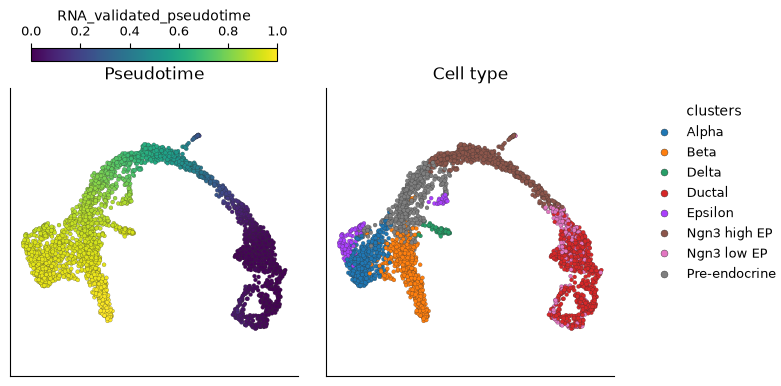

In [3]:
coverage_plot = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=[pseudotime.pseudotime_key, "clusters"],
    n_columns=2,
    show_titles=False,
    show=False,
)
for axis, title in zip(
    coverage_plot.axes.values(),
    ("Pseudotime", "Cell type"),
    strict=True,
):
    axis.set_title(title)

In [4]:
markers = ds.run_pseudotime_marker_search(
    cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
)

markers.table[
    ["feature_name", "r_value", "p_value", "p_value_adjusted"]
].head()

,feature_name,r_value,p_value,p_value_adjusted
0,Mrpl15,-0.080615,2.410271e-06,5.726456e-06
1,Vcpip1,0.019255,2.607735e-01,3.183438e-01
2,Snhg6,-0.249382,1.505228e-49,1.786404e-48
3,Tcf24,-0.003737,8.272468e-01,8.564577e-01
4,Ppp1r42,-0.031778,6.341229e-02,8.877153e-02


In [5]:
markers.table[["p_value", "p_value_adjusted"]].isna().sum()

p_value             0
p_value_adjusted    0
dtype: int64

In [6]:
modules = ds.run_pseudotime_aggregation(
    cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
    cluster_label="trajectory_modules",
    n_clusters=12,
    window_size=200,
    chunk_size=100,
)

pd.Series(modules.feature_clusters).value_counts().sort_index()

1      644
2     1687
3      820
4      727
5      675
6     1391
7     1397
8      668
9     1035
10     887
11    1511
12     954
Name: count, dtype: int64

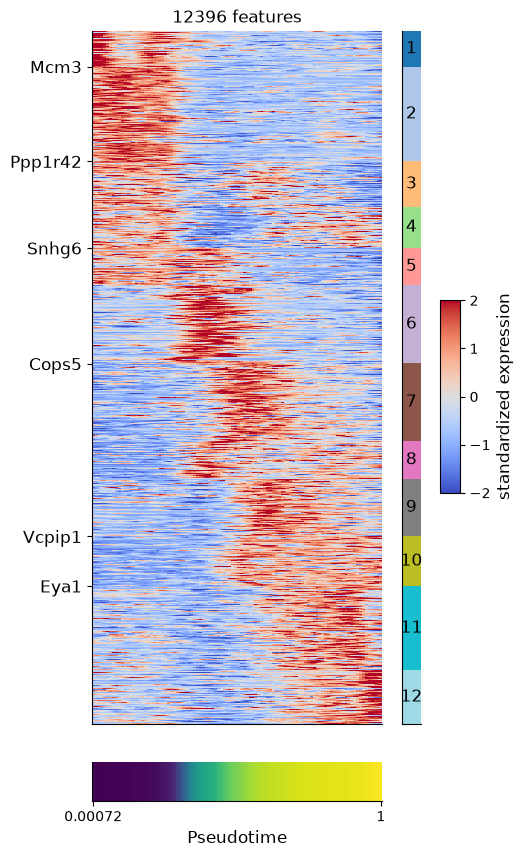

In [7]:
module_features = ds.RNA.feats.to_pandas_dataframe(
    ["names", modules.cluster_key]
)
assigned = module_features[module_features[modules.cluster_key] != -1]
representatives = (
    assigned.groupby(modules.cluster_key, sort=True)["names"]
    .first()
)
labels = representatives.iloc[::2].tolist()
ds.plots.pseudotime_heatmap(
    cell_key=modules.cell_key,
    feat_key=modules.feature_key,
    feature_cluster_key=modules.cluster_key,
    pseudotime_key=modules.pseudotime_key,
    show_features=labels,
)

In [8]:
ds.run_marker_search(group_key="clusters")
beta_markers = set(
    ds.get_markers(group_key="clusters", group_id="Beta").feature_name
)
module_overlap = (
    assigned.groupby(modules.cluster_key)["names"]
    .apply(lambda names: len(set(names) & beta_markers))
    .sort_values(ascending=False)
)
module_overlap.head()

trajectory_modules
12    56
11    28
10    16
9     11
8      4
Name: names, dtype: int64

In [9]:
fate = ds.run_fate_mapping(
    cell_key="I",
    subset_cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
    sink_key="clusters",
    sinks=["Alpha", "Beta", "Delta"],
)

valid_probabilities = fate.values[fate.valid]
simplex_error = float(
    np.max(np.abs(valid_probabilities.sum(axis=1) - 1.0))
)
simplex_error

1.1920928955078125e-07

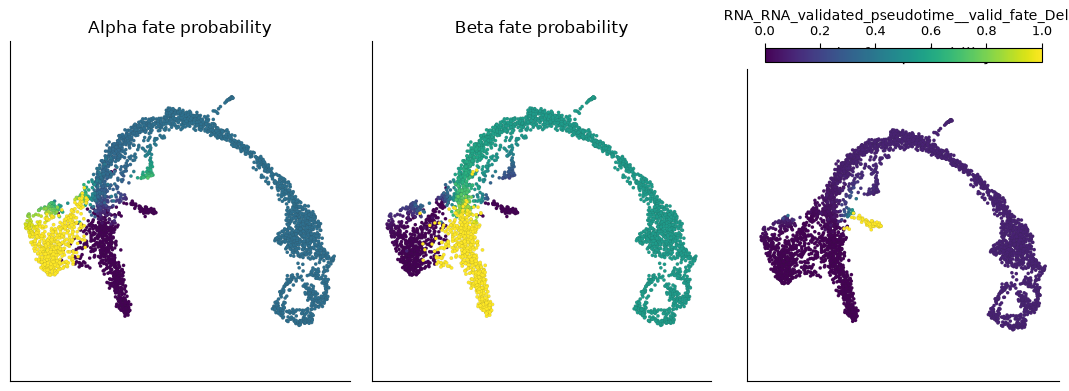

In [10]:
figure, axes = plt.subplots(1, 3, figsize=(11, 4))
probability_scale = splt.ColorScale(vmin=0, vmax=1)
for index, (axis, sink, fate_key) in enumerate(
    zip(axes, fate.sink_labels, fate.fate_keys, strict=True)
):
    ds.plots.embedding(
        layout_key="RNA_UMAP",
        color_by=fate_key,
        subset_by=fate.validity_key,
        color_scale=probability_scale,
        sort_values=True,
        show_legend=index == 2,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(f"{sink} fate probability")
figure.tight_layout()
figure

In [11]:
selected_labels = ds.cells.fetch(
    fate.sink_key,
    key=fate.result_cell_key,
)
terminal_checks = []
for index, sink in enumerate(fate.sink_labels):
    rows = (selected_labels == sink) & fate.valid
    terminal_checks.append(
        {
            "sink": sink,
            "cells": int(rows.sum()),
            "minimum own probability": float(
                fate.values[rows, index].min()
            ),
        }
    )
pd.DataFrame(terminal_checks)

,sink,cells,minimum own probability
0,Alpha,454,1.0
1,Beta,573,1.0
2,Delta,70,1.0
